In [ ]:
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
ROOT = "data/"

In [3]:
negative = pd.read_excel(ROOT + "negative.xlsx", sheet_name="Sheet1")
positive = pd.read_excel(ROOT + "positive.xlsx", sheet_name="Sheet1")

In [4]:
negative

,DRAMP_ID,Sequence,Sequence_Length,Name,Swiss_Prot_Entry,Family,Gene,Source,Activity,Protein_existence,...,N-terminal_Modification,C-terminal_Modification,Other_Modifications,Stereochemistry,Cytotoxicity,Binding_Traget,Pubmed_ID,Reference,Author,Title
0,DRAMP00089,TTKNYGNGVCNSVNWCQCGNVWASCNLATGCAAWLCKLA,39,Bacteriocin E50-52 (Preclinical),P85148,Belongs to the class IIa bacteriocin,Not found,Enterococcus faecium (Streptococcus faecium) (...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18293921,J Agric Food Chem. 2008 Mar 26;56(6):1942-1948.,"Svetoch EA, Eruslanov BV, Perelygin VV, Mitsev...",Diverse antimicrobial killing by Enterococcus ...
1,DRAMP00107,TNYGNGVGVPDAIMAGIIKLIFIFNIRQGYNFGKKAT,37,Bacteriocin L-1077,No entry found,Belongs to the class IIa bacteriocin,Not found,Lactobacillus salivarius L-1077 (NRRL B-50053)...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Not found,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,21378051,Appl Environ Microbiol. 2011 Apr;77(8):2749-27...,"Svetoch EA, Eruslanov BV, Levchuk VP, Perelygi...",Isolation of Lactobacillus salivarius 1077 (NR...
2,DRAMP00136,NRWYCNSAAGGVGGAAVCGLAGYVGEAKENIAGEVRKGWGMAGGFT...,62,Enterocin E-760 (Bacteriocin),P85147,Belongs to the class IIb bacteriocin,Not found,Enterococcus sp. (Gram-positive bacteria),"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18086839,Antimicrob Agents Chemother. 2008 Mar;52(3):10...,"Line JE, Svetoch EA, Eruslanov BV, Perelygin V...",Isolation and purification of enterocin E-760 ...
3,DRAMP00171,LIDHLGAPRWAVDTILGAIAVGNLASWVLALVPGPGWAVKAGLATA...,61,Lactocyclicin Q (Bacteriocin),B9ZZY0,Belongs to the class IIc bacteriocin,lycQ,Lactococcus sp. strain QU 12 (Gram-positive ba...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Predicted,...,Cyclization (N termini to C termini),Cyclization (C termini to N termini),The whole peptide has a cyclic structure in wh...,L,No cytotoxicity information found,Not found,19139222##21948835,Appl Environ Microbiol. 2009 Mar;75(6):1552-15...,"Sawa N, Zendo T, Kiyofuji J, Fujita K, Himeno ...",Identification and characterization of lactocy...
4,DRAMP00191,GGAGHVPEYFVGIGTPISFYG,21,Microcin J25 (MccJ25; Bacteriocin),Q9X2V7,Belongs to the class I microcin,mcjA,Escherichia coli AY25 (Gram-negative bacteria),"Antimicrobial, Antibacterial, Anti-Gram-",Protein level,...,Cyclization of a N-terminal between Gly and Glu,Free,NaN,L,No cytotoxicity information found,Not found,1429464##10092860##14531690##14531661,J Bacteriol. 1992 Nov;174(22):7428-7435.##Eur ...,"Salom³n RA, Far­as RN.##Blond A, P©duzzi J, Go...","Microcin 25, a novel antimicrobial peptide pro..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2557,DRAMP29146,GLMGTLISKQMKK,13,Pxt‐11,No entry found,Not found,Not found,Xenopus tropicalis,"Antimicrobial, Antibacterial,Anti-Gram+, Anti-...",Not found,...,Free,Amidation,The 'G' at position 1 is pyroglutamic acid,L,[Ref.25312021]No cytotoxicity information found.,Not found,25312021,FEBS J. 2015 Jan;282(1):102-13.,"Shigeri Y, Yasuda A, Hagihara Y, Nishi K, Wata...",Identification of novel peptides from amphibia...
2558,DRAMP29147,NLLGSLLKTGLKVGSNLL,18,Pxt‐12(CPF-St7),P84386,Not found,NaN,Xenopus tropicalis,"Antimicrobial, Antibacterial,Anti-Gram+, Anti-...",Protein level,...,Free,Amidation,NaN,L,[Ref.23935531]Cytotoxicity against T-lymphocyt...,liposomes,26802742##23935531,J Biochem. 2016 Jun;159(6):619-29.##PLoS Genet...,"Shigeri Y, Horie M, Yoshida T, Hagihara Y, Imu...",Physicochemical and biological characterizatio...
2559,DRAMP29148,KLLNLLPGLLAGIF,14,Reverse Pxt‐5,No entry found,Not found,Not found,Synthetic construct,"Antimicrobial, Antibacterial,Anti-Gram+, Anti-...",Not found,...,Free,Amidation,NaN,L,[Ref.26802742]No cytotoxicity information found.,liposomes,26802742,J Bio

In [5]:
positive

,DRAMP_ID,Sequence,Sequence_Length,Name,Swiss_Prot_Entry,Family,Gene,Source,Activity,Protein_existence,...,N-terminal_Modification,C-terminal_Modification,Other_Modifications,Stereochemistry,Cytotoxicity,Binding_Traget,Pubmed_ID,Reference,Author,Title
0,DRAMP00005,SLGPAIKATRQVCPKATRFVTVSCKKSDCQ,30,Epicidin 280 (Bacteriocin),O54220,Belongs to the lantibiotic family (Class I bac...,eciA,Staphylococcus epidermidis BN 280 (Gram-positi...,"Antimicrobial, Antibacterial, Anti-Gram+",Protein level,...,Oxypropionylation,Not metioned clearly,There are possible lanthionine(Lan)/3-methylla...,L,No cytotoxicity information found,Not found,9726851,Appl Environ Microbiol. 1998 Sep;64(9):3140-3146.,"Heidrich C, Pag U, Josten M, Metzger J, Jack R...","Isolation, characterization, and heterologous ..."
1,DRAMP00032,GNGVLKTISHECNMNTWQFLFTCC,24,Ruminococcin A (RumA; Bacteriocin),"P83674, P83676, P83677, Q8VLK0, Q9K381, P83675...",Belongs to the type A lantibiotic family (Clas...,rumA1 AND rumA2 AND,Ruminococcus gnavus & Ruminococcus hansenii (G...,"Antimicrobial, Antibacterial, Anti-Gram+",Protein level,...,Free,Cyclization (possibly),① It is highly probable that (i) Ser9 and the ...,L,No cytotoxicity information found,Cell membrane,11526013##11741840##12089024,Appl Environ Microbiol. 2001 Sep;67(9):4111-41...,"Dabard J, Bridonneau C, Phillipe C, Anglade P,...","Ruminococcin A, a new lantibiotic produced by ..."
2,DRAMP00068,MSWLNFLKYIAKYGKKAVSAAWKYKGKVLEWLNVGPTLEWVWQKLK...,51,Aureocin A53 (Bacteriocin),Q8GPI4,Belongs to the class II bacteriocin,aucA,Staphylococcus aureus A53 (Gram-positive bacte...,"Antimicrobial, Antibacterial, Anti-Gram+",Protein level,...,Formylation,Free,NaN,L,No cytotoxicity information found,Cell membrane,12054867,J Mol Biol. 2002 Jun 7;319(3):745-756.,"Netz DJ, Pohl R, Beck-Sickinger AG, Selmer T, ...",Biochemical characterisation and genetic analy...
3,DRAMP00069,EYHLMNGANGYLTRVNGKTVYRVTKDPVSAVFGVISNCWGSAGAGF...,50,Garvieacin Q (GarQ; Bacteriocin),No entry found,Belongs to the class II bacteriocin,Not found,Lactococcus garvieae BCC 43578 (Gram-positive ...,"Antimicrobial, Antibacterial, Anti-Gram+",Not found,...,Free,Free,NaN,L,"[Ref.22210221] Purified GarQ, up to 1 mg/mL, w...",Not found,22210221,Appl Environ Microbiol. 2012 Mar;78(5):1619-1623.,"Tosukhowong A, Zendo T, Visessanguan W, Roytra...","Garvieacin Q, a novel class II bacteriocin fro..."
4,DRAMP00074,ATRSYGNGVYCNNSKCWVNWGEAKENIAGIVISGWASGLAGMGH,44,Enterocin P (Pediocin-like peptide; Bacteriocin),"O30434, Q0GFE0",Belongs to the class IIa bacteriocin,entP,Enterococcus faecium P13 (Gram-positive bacteria),"Antimicrobial, Antibacterial, Anti-Gram+",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,9361419##17103378,Appl Environ Microbiol. 1997 Nov;63(11):4321-4...,"Cintas LM, Casaus P, H¥varstein LS, Hern¡ndez ...",Biochemical and genetic characterization of en...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2728,DRAMP29146,GLMGTLISKQMKK,13,Pxt‐11,No entry found,Not found,Not found,Xenopus tropicalis,"Antimicrobial, Antibacterial,Anti-Gram+, Anti-...",Not found,...,Free,Amidation,The 'G' at position 1 is pyroglutamic acid,L,[Ref.25312021]No cytotoxicity information found.,Not found,25312021,FEBS J. 2015 Jan;282(1):102-13.,"Shigeri Y, Yasuda A, Hagihara Y, Nishi K, Wata...",Identification of novel peptides from amphibia...
2729,DRAMP29147,NLLGSLLKTGLKVGSNLL,18,Pxt‐12(CPF-St7),P84386,Not found,NaN,Xenopus tropicalis,"Antimicrobial, Antibacterial,Anti-Gram+, Anti-...",Protein level,...,Free,Amidation,NaN,L,[Ref.23935531]Cytotoxicity against T-lymphocyt...,liposomes,26802742##23935531,J Biochem. 2016 Jun;159(6):619-29.##PLoS Genet...,"Shigeri Y, Horie M, Yoshida T, Hagihara Y, Imu...",Physicochemical and biological characterizatio...
2730,DRAMP29148,KLLNLLPGLLAGIF,14,Reverse Pxt‐5,No entry found,Not found,Not found,Synthetic construct,"Antimicrobial, Antibacterial,Anti-Gram+, Anti-...",Not found,..

In [6]:
data = pd.concat([negative, positive], axis=0, ignore_index=True)

In [7]:
data

,DRAMP_ID,Sequence,Sequence_Length,Name,Swiss_Prot_Entry,Family,Gene,Source,Activity,Protein_existence,...,N-terminal_Modification,C-terminal_Modification,Other_Modifications,Stereochemistry,Cytotoxicity,Binding_Traget,Pubmed_ID,Reference,Author,Title
0,DRAMP00089,TTKNYGNGVCNSVNWCQCGNVWASCNLATGCAAWLCKLA,39,Bacteriocin E50-52 (Preclinical),P85148,Belongs to the class IIa bacteriocin,Not found,Enterococcus faecium (Streptococcus faecium) (...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18293921,J Agric Food Chem. 2008 Mar 26;56(6):1942-1948.,"Svetoch EA, Eruslanov BV, Perelygin VV, Mitsev...",Diverse antimicrobial killing by Enterococcus ...
1,DRAMP00107,TNYGNGVGVPDAIMAGIIKLIFIFNIRQGYNFGKKAT,37,Bacteriocin L-1077,No entry found,Belongs to the class IIa bacteriocin,Not found,Lactobacillus salivarius L-1077 (NRRL B-50053)...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Not found,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,21378051,Appl Environ Microbiol. 2011 Apr;77(8):2749-27...,"Svetoch EA, Eruslanov BV, Levchuk VP, Perelygi...",Isolation of Lactobacillus salivarius 1077 (NR...
2,DRAMP00136,NRWYCNSAAGGVGGAAVCGLAGYVGEAKENIAGEVRKGWGMAGGFT...,62,Enterocin E-760 (Bacteriocin),P85147,Belongs to the class IIb bacteriocin,Not found,Enterococcus sp. (Gram-positive bacteria),"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18086839,Antimicrob Agents Chemother. 2008 Mar;52(3):10...,"Line JE, Svetoch EA, Eruslanov BV, Perelygin V...",Isolation and purification of enterocin E-760 ...
3,DRAMP00171,LIDHLGAPRWAVDTILGAIAVGNLASWVLALVPGPGWAVKAGLATA...,61,Lactocyclicin Q (Bacteriocin),B9ZZY0,Belongs to the class IIc bacteriocin,lycQ,Lactococcus sp. strain QU 12 (Gram-positive ba...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Predicted,...,Cyclization (N termini to C termini),Cyclization (C termini to N termini),The whole peptide has a cyclic structure in wh...,L,No cytotoxicity information found,Not found,19139222##21948835,Appl Environ Microbiol. 2009 Mar;75(6):1552-15...,"Sawa N, Zendo T, Kiyofuji J, Fujita K, Himeno ...",Identification and characterization of lactocy...
4,DRAMP00191,GGAGHVPEYFVGIGTPISFYG,21,Microcin J25 (MccJ25; Bacteriocin),Q9X2V7,Belongs to the class I microcin,mcjA,Escherichia coli AY25 (Gram-negative bacteria),"Antimicrobial, Antibacterial, Anti-Gram-",Protein level,...,Cyclization of a N-terminal between Gly and Glu,Free,NaN,L,No cytotoxicity information found,Not found,1429464##10092860##14531690##14531661,J Bacteriol. 1992 Nov;174(22):7428-7435.##Eur ...,"Salom³n RA, Far­as RN.##Blond A, P©duzzi J, Go...","Microcin 25, a novel antimicrobial peptide pro..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5290,DRAMP29146,GLMGTLISKQMKK,13,Pxt‐11,No entry found,Not found,Not found,Xenopus tropicalis,"Antimicrobial, Antibacterial,Anti-Gram+, Anti-...",Not found,...,Free,Amidation,The 'G' at position 1 is pyroglutamic acid,L,[Ref.25312021]No cytotoxicity information found.,Not found,25312021,FEBS J. 2015 Jan;282(1):102-13.,"Shigeri Y, Yasuda A, Hagihara Y, Nishi K, Wata...",Identification of novel peptides from amphibia...
5291,DRAMP29147,NLLGSLLKTGLKVGSNLL,18,Pxt‐12(CPF-St7),P84386,Not found,NaN,Xenopus tropicalis,"Antimicrobial, Antibacterial,Anti-Gram+, Anti-...",Protein level,...,Free,Amidation,NaN,L,[Ref.23935531]Cytotoxicity against T-lymphocyt...,liposomes,26802742##23935531,J Biochem. 2016 Jun;159(6):619-29.##PLoS Genet...,"Shigeri Y, Horie M, Yoshida T, Hagihara Y, Imu...",Physicochemical and biological characterizatio...
5292,DRAMP29148,KLLNLLPGLLAGIF,14,Reverse Pxt‐5,No entry found,Not found,Not found,Synthetic construct,"Antimicrobial, Antibacterial,Anti-Gram+, Anti-...",Not found,...,Free,Amidation,NaN,L,[Ref.26802742]No cytotoxicity information found.,liposomes,26802742,J Bio

In [8]:
data.Sequence = data.Sequence.str.replace(" ", "")
data = data[data.Sequence.str.isalpha()].copy()
data.Sequence = data.Sequence.str.upper()
data.head()

,DRAMP_ID,Sequence,Sequence_Length,Name,Swiss_Prot_Entry,Family,Gene,Source,Activity,Protein_existence,...,N-terminal_Modification,C-terminal_Modification,Other_Modifications,Stereochemistry,Cytotoxicity,Binding_Traget,Pubmed_ID,Reference,Author,Title
0,DRAMP00089,TTKNYGNGVCNSVNWCQCGNVWASCNLATGCAAWLCKLA,39,Bacteriocin E50-52 (Preclinical),P85148,Belongs to the class IIa bacteriocin,Not found,Enterococcus faecium (Streptococcus faecium) (...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18293921,J Agric Food Chem. 2008 Mar 26;56(6):1942-1948.,"Svetoch EA, Eruslanov BV, Perelygin VV, Mitsev...",Diverse antimicrobial killing by Enterococcus ...
1,DRAMP00107,TNYGNGVGVPDAIMAGIIKLIFIFNIRQGYNFGKKAT,37,Bacteriocin L-1077,No entry found,Belongs to the class IIa bacteriocin,Not found,Lactobacillus salivarius L-1077 (NRRL B-50053)...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Not found,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,21378051,Appl Environ Microbiol. 2011 Apr;77(8):2749-27...,"Svetoch EA, Eruslanov BV, Levchuk VP, Perelygi...",Isolation of Lactobacillus salivarius 1077 (NR...
2,DRAMP00136,NRWYCNSAAGGVGGAAVCGLAGYVGEAKENIAGEVRKGWGMAGGFT...,62,Enterocin E-760 (Bacteriocin),P85147,Belongs to the class IIb bacteriocin,Not found,Enterococcus sp. (Gram-positive bacteria),"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18086839,Antimicrob Agents Chemother. 2008 Mar;52(3):10...,"Line JE, Svetoch EA, Eruslanov BV, Perelygin V...",Isolation and purification of enterocin E-760 ...
3,DRAMP00171,LIDHLGAPRWAVDTILGAIAVGNLASWVLALVPGPGWAVKAGLATA...,61,Lactocyclicin Q (Bacteriocin),B9ZZY0,Belongs to the class IIc bacteriocin,lycQ,Lactococcus sp. strain QU 12 (Gram-positive ba...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Predicted,...,Cyclization (N termini to C termini),Cyclization (C termini to N termini),The whole peptide has a cyclic structure in wh...,L,No cytotoxicity information found,Not found,19139222##21948835,Appl Environ Microbiol. 2009 Mar;75(6):1552-15...,"Sawa N, Zendo T, Kiyofuji J, Fujita K, Himeno ...",Identification and characterization of lactocy...
4,DRAMP00191,GGAGHVPEYFVGIGTPISFYG,21,Microcin J25 (MccJ25; Bacteriocin),Q9X2V7,Belongs to the class I microcin,mcjA,Escherichia coli AY25 (Gram-negative bacteria),"Antimicrobial, Antibacterial, Anti-Gram-",Protein level,...,Cyclization of a N-terminal between Gly and Glu,Free,NaN,L,No cytotoxicity information found,Not found,1429464##10092860##14531690##14531661,J Bacteriol. 1992 Nov;174(22):7428-7435.##Eur ...,"Salom³n RA, Far­as RN.##Blond A, P©duzzi J, Go...","Microcin 25, a novel antimicrobial peptide pro..."


In [9]:
data.drop_duplicates(subset=["Sequence"], inplace=True, keep="first", ignore_index=True)
data = data[~data.Sequence.str.contains("[BJOUXZ]", regex=True)].copy()
data

,DRAMP_ID,Sequence,Sequence_Length,Name,Swiss_Prot_Entry,Family,Gene,Source,Activity,Protein_existence,...,N-terminal_Modification,C-terminal_Modification,Other_Modifications,Stereochemistry,Cytotoxicity,Binding_Traget,Pubmed_ID,Reference,Author,Title
0,DRAMP00089,TTKNYGNGVCNSVNWCQCGNVWASCNLATGCAAWLCKLA,39,Bacteriocin E50-52 (Preclinical),P85148,Belongs to the class IIa bacteriocin,Not found,Enterococcus faecium (Streptococcus faecium) (...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18293921,J Agric Food Chem. 2008 Mar 26;56(6):1942-1948.,"Svetoch EA, Eruslanov BV, Perelygin VV, Mitsev...",Diverse antimicrobial killing by Enterococcus ...
1,DRAMP00107,TNYGNGVGVPDAIMAGIIKLIFIFNIRQGYNFGKKAT,37,Bacteriocin L-1077,No entry found,Belongs to the class IIa bacteriocin,Not found,Lactobacillus salivarius L-1077 (NRRL B-50053)...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Not found,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,21378051,Appl Environ Microbiol. 2011 Apr;77(8):2749-27...,"Svetoch EA, Eruslanov BV, Levchuk VP, Perelygi...",Isolation of Lactobacillus salivarius 1077 (NR...
2,DRAMP00136,NRWYCNSAAGGVGGAAVCGLAGYVGEAKENIAGEVRKGWGMAGGFT...,62,Enterocin E-760 (Bacteriocin),P85147,Belongs to the class IIb bacteriocin,Not found,Enterococcus sp. (Gram-positive bacteria),"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18086839,Antimicrob Agents Chemother. 2008 Mar;52(3):10...,"Line JE, Svetoch EA, Eruslanov BV, Perelygin V...",Isolation and purification of enterocin E-760 ...
3,DRAMP00171,LIDHLGAPRWAVDTILGAIAVGNLASWVLALVPGPGWAVKAGLATA...,61,Lactocyclicin Q (Bacteriocin),B9ZZY0,Belongs to the class IIc bacteriocin,lycQ,Lactococcus sp. strain QU 12 (Gram-positive ba...,"Antimicrobial, Antibacterial, Anti-Gram+, Anti...",Predicted,...,Cyclization (N termini to C termini),Cyclization (C termini to N termini),The whole peptide has a cyclic structure in wh...,L,No cytotoxicity information found,Not found,19139222##21948835,Appl Environ Microbiol. 2009 Mar;75(6):1552-15...,"Sawa N, Zendo T, Kiyofuji J, Fujita K, Himeno ...",Identification and characterization of lactocy...
4,DRAMP00191,GGAGHVPEYFVGIGTPISFYG,21,Microcin J25 (MccJ25; Bacteriocin),Q9X2V7,Belongs to the class I microcin,mcjA,Escherichia coli AY25 (Gram-negative bacteria),"Antimicrobial, Antibacterial, Anti-Gram-",Protein level,...,Cyclization of a N-terminal between Gly and Glu,Free,NaN,L,No cytotoxicity information found,Not found,1429464##10092860##14531690##14531661,J Bacteriol. 1992 Nov;174(22):7428-7435.##Eur ...,"Salom³n RA, Far­as RN.##Blond A, P©duzzi J, Go...","Microcin 25, a novel antimicrobial peptide pro..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2944,DRAMP29005,KLLKLLK,7,Unstapled heptapeptide 9,No entry found,NaN,NaN,Synthetic construct,"Antimicrobial, Antibacterial, Anti-Gram+",Synthetic form,...,Free,Amidation,NaN,L,No cytotoxicity information found in the refer...,NaN,PubMed ID is not available,Int J Pept Res Ther. 2019 Nov 14; 26(4):1711–1...,"Zhixia Chen, Xiuli Yu, Aiying Zhang, Fangfang ...",De Novo Hydrocarbon-Stapling Design of Single-...
2945,DRAMP29063,FLQRIIGARGRLF,13,GHaR9R (variant of temporin-GHaR),No entry found,Not found,NaN,Synthetic construct,"Antimicrobial, Antibacterial, Anti-Gram+",Synthetic form,...,Free,Free,NaN,L,Not found,Cell membrane,33291521,Molecules. 2020 Dec 4;25(23):5724. doi: 10.339...,"Wei H, Xie Z, Tan X, Guo R, Song Y, Xie X, Wan...",Temporin-Like Peptides Show Antimicrobial and ...
2946,DRAMP29068,KFWSLLKKALRLWKKVL,17,CPF-2-1 (Variant of CPF-C1),No entry found,Not found,NaN,Synthetic construct,"Antimicrobial, Antibacterial, Anti-Gram+",Synthetic form,...,Free,Amidation,Introduction of D-amino acid(s). (Look at 'Ste...,"Mixed (D-Lys1, D-Trp3, D-Lys7, D-Leu10, D-Arg1...",Not found,Bacterial

In [10]:
data.isnull().sum()

DRAMP_ID                      0
Sequence                      0
Sequence_Length               0
Name                          0
Swiss_Prot_Entry              0
Family                       32
Gene                        113
Source                        0
Activity                      0
Protein_existence           110
Structure                     1
Structure_Description         0
PDB_ID                     2697
Comments                      0
Target_Organism               0
Hemolytic_activity            0
Linear/Cyclic/Branched        1
N-terminal_Modification       1
C-terminal_Modification       1
Other_Modifications         680
Stereochemistry               1
Cytotoxicity                  1
Binding_Traget               13
Pubmed_ID                     1
Reference                     1
Author                        1
Title                         3
dtype: int64

In [11]:
data.Activity = data.Activity.str.lower()

In [12]:
data[
    (~data.Activity.str.contains("anti-gram+", regex=False))
    & (~data.Activity.str.contains("anti-gram-", regex=False))
].shape

(0, 27)

In [13]:
data[
    (data.Activity.str.contains("anti-gram+", regex=False))
    & (~data.Activity.str.contains("anti-gram-", regex=False))
].shape

(481, 27)

In [14]:
data[
    (~data.Activity.str.contains("anti-gram+", regex=False))
    & (data.Activity.str.contains("anti-gram-", regex=False))
].shape

(339, 27)

In [15]:
data[
    (data.Activity.str.contains("anti-gram+", regex=False))
    & (data.Activity.str.contains("anti-gram-", regex=False))
].shape

(2067, 27)

In [16]:
data.loc[
    (
        (data.Activity.str.contains("anti-gram+", regex=False))
        & (~data.Activity.str.contains("anti-gram-", regex=False))
    ),
    "Activity",
] = "positive"

data.loc[
    (
        (~data.Activity.str.contains("anti-gram+", regex=False))
        & (data.Activity.str.contains("anti-gram-", regex=False))
    ),
    "Activity",
] = "negative"

data.loc[
    (
        (data.Activity.str.contains("anti-gram+", regex=False))
        & (data.Activity.str.contains("anti-gram-", regex=False))
    ),
    "Activity",
] = "positive, negative"

In [17]:
data.Activity.value_counts()

Activity
positive, negative    2067
positive               481
negative               339
Name: count, dtype: int64

In [18]:
data[["Sequence", "Activity"]]
data

,DRAMP_ID,Sequence,Sequence_Length,Name,Swiss_Prot_Entry,Family,Gene,Source,Activity,Protein_existence,...,N-terminal_Modification,C-terminal_Modification,Other_Modifications,Stereochemistry,Cytotoxicity,Binding_Traget,Pubmed_ID,Reference,Author,Title
0,DRAMP00089,TTKNYGNGVCNSVNWCQCGNVWASCNLATGCAAWLCKLA,39,Bacteriocin E50-52 (Preclinical),P85148,Belongs to the class IIa bacteriocin,Not found,Enterococcus faecium (Streptococcus faecium) (...,"positive, negative",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18293921,J Agric Food Chem. 2008 Mar 26;56(6):1942-1948.,"Svetoch EA, Eruslanov BV, Perelygin VV, Mitsev...",Diverse antimicrobial killing by Enterococcus ...
1,DRAMP00107,TNYGNGVGVPDAIMAGIIKLIFIFNIRQGYNFGKKAT,37,Bacteriocin L-1077,No entry found,Belongs to the class IIa bacteriocin,Not found,Lactobacillus salivarius L-1077 (NRRL B-50053)...,"positive, negative",Not found,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,21378051,Appl Environ Microbiol. 2011 Apr;77(8):2749-27...,"Svetoch EA, Eruslanov BV, Levchuk VP, Perelygi...",Isolation of Lactobacillus salivarius 1077 (NR...
2,DRAMP00136,NRWYCNSAAGGVGGAAVCGLAGYVGEAKENIAGEVRKGWGMAGGFT...,62,Enterocin E-760 (Bacteriocin),P85147,Belongs to the class IIb bacteriocin,Not found,Enterococcus sp. (Gram-positive bacteria),"positive, negative",Protein level,...,Free,Free,NaN,L,No cytotoxicity information found,Not found,18086839,Antimicrob Agents Chemother. 2008 Mar;52(3):10...,"Line JE, Svetoch EA, Eruslanov BV, Perelygin V...",Isolation and purification of enterocin E-760 ...
3,DRAMP00171,LIDHLGAPRWAVDTILGAIAVGNLASWVLALVPGPGWAVKAGLATA...,61,Lactocyclicin Q (Bacteriocin),B9ZZY0,Belongs to the class IIc bacteriocin,lycQ,Lactococcus sp. strain QU 12 (Gram-positive ba...,"positive, negative",Predicted,...,Cyclization (N termini to C termini),Cyclization (C termini to N termini),The whole peptide has a cyclic structure in wh...,L,No cytotoxicity information found,Not found,19139222##21948835,Appl Environ Microbiol. 2009 Mar;75(6):1552-15...,"Sawa N, Zendo T, Kiyofuji J, Fujita K, Himeno ...",Identification and characterization of lactocy...
4,DRAMP00191,GGAGHVPEYFVGIGTPISFYG,21,Microcin J25 (MccJ25; Bacteriocin),Q9X2V7,Belongs to the class I microcin,mcjA,Escherichia coli AY25 (Gram-negative bacteria),negative,Protein level,...,Cyclization of a N-terminal between Gly and Glu,Free,NaN,L,No cytotoxicity information found,Not found,1429464##10092860##14531690##14531661,J Bacteriol. 1992 Nov;174(22):7428-7435.##Eur ...,"Salom³n RA, Far­as RN.##Blond A, P©duzzi J, Go...","Microcin 25, a novel antimicrobial peptide pro..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2944,DRAMP29005,KLLKLLK,7,Unstapled heptapeptide 9,No entry found,NaN,NaN,Synthetic construct,positive,Synthetic form,...,Free,Amidation,NaN,L,No cytotoxicity information found in the refer...,NaN,PubMed ID is not available,Int J Pept Res Ther. 2019 Nov 14; 26(4):1711–1...,"Zhixia Chen, Xiuli Yu, Aiying Zhang, Fangfang ...",De Novo Hydrocarbon-Stapling Design of Single-...
2945,DRAMP29063,FLQRIIGARGRLF,13,GHaR9R (variant of temporin-GHaR),No entry found,Not found,NaN,Synthetic construct,positive,Synthetic form,...,Free,Free,NaN,L,Not found,Cell membrane,33291521,Molecules. 2020 Dec 4;25(23):5724. doi: 10.339...,"Wei H, Xie Z, Tan X, Guo R, Song Y, Xie X, Wan...",Temporin-Like Peptides Show Antimicrobial and ...
2946,DRAMP29068,KFWSLLKKALRLWKKVL,17,CPF-2-1 (Variant of CPF-C1),No entry found,Not found,NaN,Synthetic construct,positive,Synthetic form,...,Free,Amidation,Introduction of D-amino acid(s). (Look at 'Ste...,"Mixed (D-Lys1, D-Trp3, D-Lys7, D-Leu10, D-Arg1...",Not found,Bacterial membrane,32590058,Biochimie. 2020 Sep;176:1-11. doi: 10.1016/j.b...,"Xie J, Li Y, Guo X, Rao J, Yan T, Mou L, Wu X,...",CPF-C1 analog with effective antimicrobial and...
2947,DRAMP29069,KFWSLLKKALRLWAKVL,17,CPF-2-2 (Variant of CPF-C1),No entry found,Not found

In [19]:
data[["Sequence", "Activity"]].to_csv(ROOT + "raw_data.csv", index=False)

In [20]:
data = data[["Sequence", "Activity", "Target_Organism"]]

In [21]:
def get_categories(text: str) -> set[str]:
    categories = set()
    l = text.split("##")
    for s in l:
        s = s.strip()
        categories.add(re.sub(r"[^a-zA-Z]", "", s.split(" ")[0]).lower())
    return categories

In [22]:
categories = set().union(*data.Target_Organism.dropna().apply(get_categories))


def exctract_gram_negative(target_organisms: list[str]) -> list[str]:
    result = []
    flag = False
    for text in target_organisms:
        text = text.lower()
        text = text.strip()
        if "gram" in text and "pos" in text:
            flag = False
        elif "gram" in text and "neg" in text:
            flag = True
        elif text:
            first = re.sub(r"[^a-zA-Z]", "", text.split(" ")[0])
            if len(first) > 2 and first in categories and "mic" not in text:
                flag = False
            else:
                if flag:
                    result.append(text)
    return result

In [23]:
def splitter(text: str) -> list[str]:
    text = text.lower()
    pattern = re.compile(r": |,|;|##| and |bacteria:|bacterium:")
    result = []
    last = 0
    bracket = 0

    idx = 0
    while idx < len(text):
        if text[idx] == "(":
            bracket += 1
        elif text[idx] == ")":
            bracket -= 1

        if bracket <= 0:
            match = pattern.match(text, idx)
            if match:
                result.append(text[last:idx])
                last = match.end()
                idx = last
                continue
        idx += 1
    result.append(text[last:])
    return result

In [24]:
data.loc[:, "Gram_Negative"] = (
    data["Target_Organism"]
    .str.replace(r"\s", " ", regex=True)
    .apply(splitter)
    .apply(exctract_gram_negative)
)

/tmp/ipykernel_3434/2408115214.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Gram_Negative"] = (


In [25]:
data["Gram_Negative"]

0       [campylobacter jejuni (mic=0.025-6.4 µg/ml), y...
1       [salmonella enteritidis 1 (mic=0.19 ug/ml), s....
2       [s. enterica serovar enteritidis 1 (mic=0.2 μg...
3       [escherichia coli jm109 (mic=34.3 µm), e. coli...
4       [escherichia coli bm21 (mic=0.08 µg/ml), e. co...
                              ...                        
2944                                                   []
2945    [e. coli(mic / mbc > 50μm / 50μm), d31(mic / m...
2946                                                   []
2947                                                   []
2948                                                   []
Name: Gram_Negative, Length: 2887, dtype: object

In [26]:
freq = defaultdict(int)

for target_organisms in data["Gram_Negative"].dropna():
    for target_organism in target_organisms:
        freq[
            re.sub(
                r"\s+",
                " ",
                re.sub(
                    r"[^a-zA-Z\s]+",
                    " ",
                    " ".join(target_organism.split("(")[0].split(" ")[:2]),
                ),
            ).strip()
        ] += 1

In [27]:
data

,Sequence,Activity,Target_Organism,Gram_Negative
0,TTKNYGNGVCNSVNWCQCGNVWASCNLATGCAAWLCKLA,"positive, negative",Gram-negative bacteria: Campylobacter jejuni (...,"[campylobacter jejuni (mic=0.025-6.4 µg/ml), y..."
1,TNYGNGVGVPDAIMAGIIKLIFIFNIRQGYNFGKKAT,"positive, negative",Gram-negative bacteria: Salmonella Enteritidis...,"[salmonella enteritidis 1 (mic=0.19 ug/ml), s...."
2,NRWYCNSAAGGVGGAAVCGLAGYVGEAKENIAGEVRKGWGMAGGFT...,"positive, negative",[Ref.18086839]Gram-positive bacteria: Listeria...,[s. enterica serovar enteritidis 1 (mic=0.2 μg...
3,LIDHLGAPRWAVDTILGAIAVGNLASWVLALVPGPGWAVKAGLATA...,"positive, negative",Gram-positive bacteria: Lactococcus sp.strain ...,"[escherichia coli jm109 (mic=34.3 µm), e. coli..."
4,GGAGHVPEYFVGIGTPISFYG,negative,Gram-negative bacteria: Escherichia coli BM21 ...,"[escherichia coli bm21 (mic=0.08 µg/ml), e. co..."
...,...,...,...,...
2944,KLLKLLK,positive,Gram-positive bacteria: Staphylococcus aureus ...,[]
2945,FLQRIIGARGRLF,positive,[Ref.33291521] Gram-positive bacteria: S. aure...,"[e. coli(mic / mbc > 50μm / 50μm), d31(mic / m..."
2946,KFWSLLKKALRLWKKVL,positive,[Ref.32590058] Gram-positive: S. aureus ATCC 2...,[]
2947,KFWSLLKKALRLWAKVL,positive,[Ref.32590058] Gram-positive: S. aureus ATCC 2...,[]


In [28]:
gram_negative_series = data["Gram_Negative"].apply(pd.Series)
df = pd.concat([data.drop(columns="Gram_Negative"), gram_negative_series], axis=1)
df

,Sequence,Activity,Target_Organism,0,1,2,3,4,5,6,...,27,28,29,30,31,32,33,34,35,36
0,TTKNYGNGVCNSVNWCQCGNVWASCNLATGCAAWLCKLA,"positive, negative",Gram-negative bacteria: Campylobacter jejuni (...,campylobacter jejuni (mic=0.025-6.4 µg/ml),yersinia enterocolitica,yersinia pseudotuberculosis,escherichia coli o157:h7 (mic<1.6 µg/ml),NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TNYGNGVGVPDAIMAGIIKLIFIFNIRQGYNFGKKAT,"positive, negative",Gram-negative bacteria: Salmonella Enteritidis...,salmonella enteritidis 1 (mic=0.19 ug/ml),s. enteritidis 4 (mic=0.38 ug/ml),s. enteritidis 204 (mic=0.38 ug/ml),s. enteritidis 237 (mic=0.19 ug/ml),salmonella choleraesuis 434/4 (mic=0.38 ug/ml),s. choleraesuis 370 (mic=0.19 ug/ml),salmonella typhimurium 483/6 (mic=0.19 ug/ml),...,campylobacter jejuni l-4 (mic=0.09 ug/ml),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NRWYCNSAAGGVGGAAVCGLAGYVGEAKENIAGEVRKGWGMAGGFT...,"positive, negative",[Ref.18086839]Gram-positive bacteria: Listeria...,s. enterica serovar enteritidis 1 (mic=0.2 μg/ml),s. enterica serovar enteritidis 4 (mic=0.4 μg/ml),s. enterica serovar enteritidis 204 (mic=0.2 μ...,s. enterica serovar enteritidis 237 (mic=0.2 μ...,s. enterica serovar choleraesuis 434/4 (mic=0....,s. enterica serovar choleraesuis 370 (mic=0.4 ...,s. enterica serovar typhimurium 383/60 (mic=0....,...,campylobacter lb 6-r (mic=0.1 μg/ml),campylobacter c/d (mic=0.2 μg/ml),.,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LIDHLGAPRWAVDTILGAIAVGNLASWVLALVPGPGWAVKAGLATA...,"positive, negative",Gram-positive bacteria: Lactococcus sp.strain ...,escherichia coli jm109 (mic=34.3 µm),e. coli nbrc 3301 (mic=17.3 µm).,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GGAGHVPEYFVGIGTPISFYG,negative,Gram-negative bacteria: Escherichia coli BM21 ...,escherichia coli bm21 (mic=0.08 µg/ml),e. coli ab1133 (mic=0.02 µg/ml),e. coli ryc816 (mic=0.04 µg/ml),e. coli ay29 (mic=0.04 µg/ml),salmonella species,shigella flexneri.,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2944,KLLKLLK,positive,Gram-positive bacteria: Staphylococcus aureus ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2945,FLQRIIGARGRLF,positive,[Ref.33291521] Gram-positive bacteria: S. aure...,e. coli(mic / mbc > 50μm / 50μm),d31(mic / mbc > 50μm / 50μm),p. aeruginosa(mic / mbc > 50μm / 50μm),pao1(mic / mbc > 50μm / 50μm),NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2946,KFWSLLKKALRLWKKVL,positive,[Ref.32590058] Gram-positive: S. aureus ATCC 2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2947,KFWSLLKKALRLWAKVL,positive,[Ref.32590058] Gram-positive: S. aureus ATCC 2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
def fix_unicode_escapes(x):
    if not isinstance(x, str):
        return x
    return re.sub(r"\\u([0-9a-fA-F]{4})", lambda m: chr(int(m.group(1), 16)), x)

In [30]:
df = df.apply(lambda col: col.map(fix_unicode_escapes))
df.to_csv(ROOT + "negative_species.csv", encoding="utf-8-sig", index=False)

In [31]:
len(freq)

365

In [32]:
merged = {
    "Escherichia coli": 2756,
    "Pseudomonas aeruginosa": 1713,
    "Salmonella": 711,
    "Klebsiella pneumoniae": 451,
    "Acinetobacter baumannii": 227,
    "Shigella": 109,
    "Enterobacter cloacae": 113,
    "Serratia marcescens": 68,
    "Aeromonas salmonicida": 59,
    "Staphylococcus aureus": 52,
    "Proteus vulgaris": 50,
    "Yersinia": 47,
    "Proteus mirabilis": 47,
    "Klebsiella oxytoca": 44,
    "Stenotrophomonas maltophilia": 34,
    "Enterobacter aerogenes": 31,
    "Erwinia carotovora": 28,
    "Pseudomonas syringae": 28,
    "Pseudomonas putida": 26,
    "Vibrio anguillarum": 24,
    "Vibrio parahaemolyticus": 24,
    "Helicobacter pylori": 21,
    "Xanthomonas campestris": 20,
    "Psychrobacter faecalis": 19,
    "Pseudomonas fluorescens": 18,
    "Acinetobacter calcoaceticus": 17,
    "Vibrio vulnificus": 16,
    "Xanthomonas oryzae": 16,
    "Pasteurella multocida": 15,
    "Vibrio harveyi": 13,
    "Legionella": 13,
    "Citrobacter": 13,
    "Saccharomyces cerevisiae": 12,
    "Burkholderia cepacia": 12,
    "Porphyromonas gingivalis": 11,
    "Candida albicans": 11,
    "Serratia rubidaea": 11,
    "Alcaligenes faecalis": 10,
    "Agrobacterium tumefaciens": 10,
    "Listeria": 10,
    "Shewanella": 10,
    "Vibrio alginolyticus": 9,
    "Moraxella catarrhalis": 9,
    "Agrobacterium radiobacter": 9,
    "Agrobacterium rhizogenes": 9,
    "Serratia sp.": 8,
    "Photobacterium damselae": 8,
    "Haemophilus influenzae": 8,
    "Ralstonia solanacearum": 7,
    "Klebsiella sp.": 7,
    "Pasteurella haemolytica": 6,
    "Neisseria gonorrhoeae": 6,
    "Vibrio cholerae": 6,
    "Flavobacterium meningosepticum": 6,
    "Xenorhabdus nematophilus": 6,
    "Campylobacter jejuni": 5,
    "Campylobacter sp.": 5,
    "Vibrio sp.": 5,
    "Rhizobium meliloti": 5,
    "Erwinia salicis": 5,
    "Erwinia persicinus": 5,
    "Enterobacter sp.": 4,
    "Proteus sp.": 4,
    "Xanthomonas albilineans": 4,
    "Zymomonas mobilis": 4,
    "Micrococcus luteus": 4,
    "Acidovorax konjaci": 4,
    "Acinetobacter sp.": 4,
    "Vibrio penaeicida": 3,
    "Edwardsiella tarda": 3,
    "Neisseria sp.": 3,
    "Mycobacterium": 2,
    "Vibrio metschnikovii": 2,
    "Morganella morganii": 2,
    "Propionibacterium": 2,
    "Spiroplasma melliferum": 2,
    "Acholeplasma laidlawii": 2,
    "Saccharibacillus kuerlensis": 2,
    "Xenorhabdus japonicus": 2,
    "Lactobacillus casei": 2,
    "Lactobacillus rhamnosus": 2,
    "Xanthomonas vesicatoria": 2,
    "Cytophaga": 2,
    "Pseudomonas lachrymans": 2,
    "Pseudomonas otitidis": 2,
    "Erwinia amylovora": 2,
    "Erwinia herbicola": 2,
    "Enterococcus faecalis": 2,
    "Neisseria meningitidis": 1,
    "Candida tropicalis": 1,
    "Cryptococcus neoformans": 1,
    "Hafnia alvei": 1,
    "Providencia rettgeri": 1,
    "Bdellovibrio bacteriovorus": 1,
    "Caulobacter crescentus": 1,
    "Corynebacterium diphtheriae": 1,
    "Leucothrix mucor": 1,
    "Streptococcus pyogenes": 1,
    "Enterococcus faecium": 1,
    "Lactobacillus plantarum": 1,
    "Sodalis": 1,
    "Plesiomonas shigelloides": 1,
    "Bacillus pumilus": 1,
    "Achromobacter xylosoxidans": 1,
    "Alcaligenes denitrificans": 1,
    "Alteromonas carrageenovora": 1,
    "Vibrio ichthyoenteri": 1,
    "Vibrio splendidus": 1,
    "Vibrio fluvialis": 1,
    "Pseudomonas cichorii": 1,
    "Pseudomonas glumae": 1,
    "Pseudomonas plantarii": 1,
    "Pseudomonas luteola": 1,
    "Pseudomonas reptilivora": 1,
    "Pseudomonas alginovora": 1,
    "Xanthomonas citri": 1,
    "Sphingobacterium siyangense": 1,
}

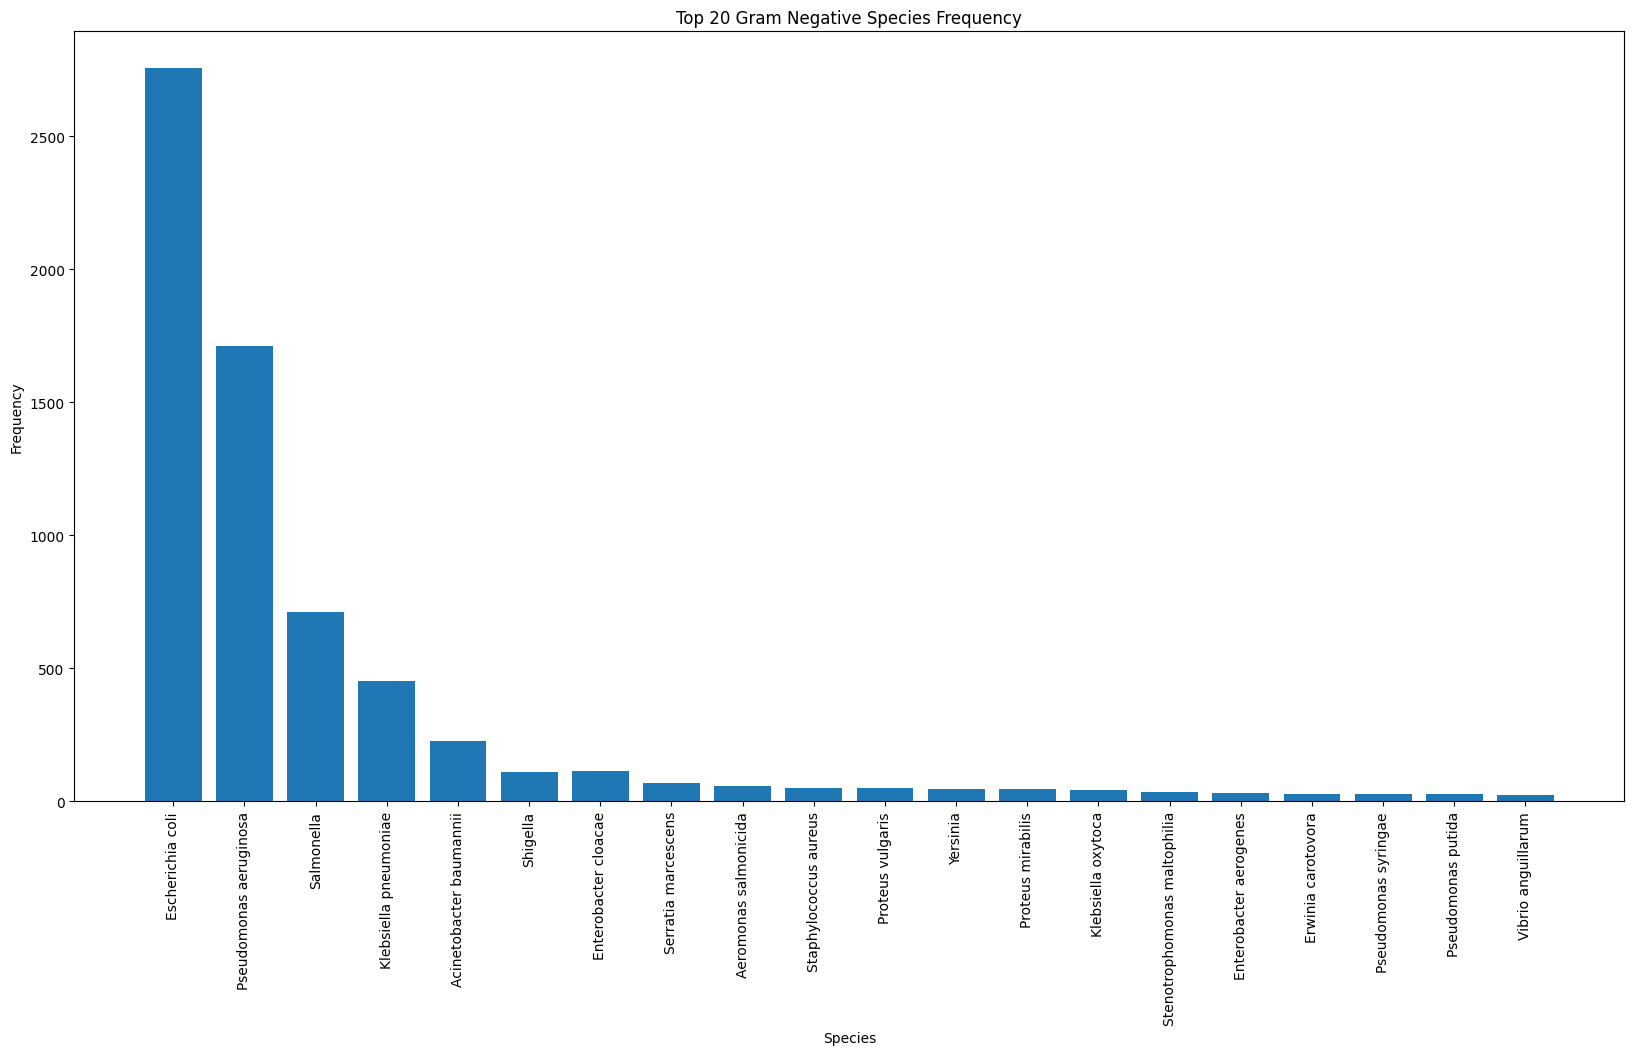

In [33]:
plt.figure(figsize=(20, 10))
plt.bar(list(merged.keys())[:20], list(merged.values())[:20])
plt.xticks(rotation=90)
plt.xlabel("Species")
plt.ylabel("Frequency")
plt.title("Top 20 Gram Negative Species Frequency")
plt.show()

In [35]:
ns = pd.DataFrame(merged.items(), columns=["Species", "Frequency"])
ns

,Species,Frequency
0,Escherichia coli,2756
1,Pseudomonas aeruginosa,1713
2,Salmonella,711
3,Klebsiella pneumoniae,451
4,Acinetobacter baumannii,227
...,...,...
112,Pseudomonas luteola,1
113,Pseudomonas reptilivora,1
114,Pseudomonas alginovora,1
115,Xanthomonas citri,1


In [36]:
ns.to_excel(ROOT + "negative_species_frequency.xlsx", index=False)